# Particle Root File Display (Cleaned)

Lean exploration of one ROOT file with configurable filters and compact plots.

## 1) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import uproot
import awkward as ak

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)

## 2) Config + Load ROOT File

In [2]:
# FILE_PATH = "/vols/comet/users/jcassens/MC7/downstream/oa_g4_xxx_00000001-0000_cfmyfe5bzdtl_SG4_000.root"
# TREE_NAME = "SIMG4/RooTrackerTree;101"
FILE_PATH = "/home/hep/jcc525/comet_data/midstream_merged00000001.rootracker"
# FILE_PATH = "/home/hep/jcc525/gan_particle_physics/gan_results/e_theta_constraint/smoke_export.rootracker"
TREE_NAME = "RooTrackerTree;1"

with uproot.open(FILE_PATH) as root_file:
    tree = root_file[TREE_NAME]
    arrays = tree.arrays(["StdHepPdg", "StdHepP4", "StdHepX4", "MonitorID"], library="ak")

pdg = ak.flatten(arrays["StdHepPdg"])
p4 = ak.flatten(arrays["StdHepP4"])
x4 = ak.flatten(arrays["StdHepX4"])
monitor_id = ak.flatten(arrays["MonitorID"])

base_df = pd.DataFrame({
    "pdg": ak.to_numpy(pdg),
    "px": ak.to_numpy(p4[:, 0]),
    "py": ak.to_numpy(p4[:, 1]),
    "pz": ak.to_numpy(p4[:, 2]),
    "t": ak.to_numpy(p4[:, 3]),
    "x": ak.to_numpy(x4[:, 0]),
    "y": ak.to_numpy(x4[:, 1]),
    "z": ak.to_numpy(x4[:, 2]),
    "monitor_id": ak.to_numpy(monitor_id),
})

base_df["p_mag"] = np.sqrt(base_df["px"]**2 + base_df["py"]**2 + base_df["pz"]**2)
base_df["log_t"] = np.log(base_df["t"] + 1e-10)

print(f"Loaded {len(base_df):,} records from: {FILE_PATH}")
print(f"Tree entries: {tree.num_entries:,}")
print(f"MonitorIDs: {sorted(base_df['monitor_id'].unique())}")
base_df.head()

Loaded 50,485 records from: /home/hep/jcc525/comet_data/midstream_merged00000001.rootracker
Tree entries: 1,000,000
MonitorIDs: [1, 2, 3, 4]


,pdg,px,py,pz,t,x,y,z,monitor_id,p_mag,log_t
0,11,0.460324,-0.030095,-0.287904,0.746199,3258.960000,59.712856,7685.930007,4,0.543776,-0.292764
1,22,0.091715,-0.016737,0.008641,0.093630,4936.154477,1023.624866,801.530873,2,0.093630,-2.368409
2,13,97.513336,12.950654,-20.034248,145.745095,3258.960000,-176.349560,7672.932750,4,100.388949,4.981859
3,11,29.972658,23.145785,-6.561947,38.437063,3258.960000,25.408234,7699.266033,4,38.433666,3.649022
4,22,0.308929,-0.302769,0.272055,0.510999,3258.960000,124.919929,7702.011674,4,0.510999,-0.671388


## 3) Particle Map (Maintained)

In [3]:
particle_map = {
    11: "electron", -11: "positron",
    13: "muon-", -13: "muon+",
    15: "tau-", -15: "tau+",
    12: "nu_e", -12: "nu_e_bar",
    14: "nu_mu", -14: "nu_mu_bar",
    16: "nu_tau", -16: "nu_tau_bar",
    22: "photon",
    23: "Z0",
    24: "W+", -24: "W-",
    111: "pi0", 211: "pi+", -211: "pi-",
    311: "K0", 321: "K+", -321: "K-",
    2212: "proton", -2212: "antiproton",
    2112: "neutron", -2112: "antineutron",
}

base_df["particle"] = base_df["pdg"].map(particle_map)
mapped_df = base_df.dropna(subset=["particle"]).copy()

print(f"Mapped records: {len(mapped_df):,} / {len(base_df):,}")
mapped_df["particle"].value_counts().head(20)

Mapped records: 50,485 / 50,485


particle
photon      28898
neutron      7680
electron     7584
muon-        4737
positron     1221
pi-           330
muon+          27
proton          8
Name: count, dtype: int64

In [4]:
# Filters (maintained, now centralized)
MONITOR_FILTER = [4]     # set None to disable, or [3, 4] for monitors 3 and 4 only
PARTICLE_INCLUDE = None      # e.g. ['muon-', 'muon+'] or None
MAX_POINTS_PLOT = 120000

filtered_df = mapped_df.copy()
if MONITOR_FILTER is not None:
    filtered_df = filtered_df[filtered_df["monitor_id"].isin(MONITOR_FILTER)]
if PARTICLE_INCLUDE is not None:
    filtered_df = filtered_df[filtered_df["particle"].isin(PARTICLE_INCLUDE)]

plot_df = filtered_df.copy()
if len(plot_df) > MAX_POINTS_PLOT:
    plot_df = plot_df.sample(n=MAX_POINTS_PLOT, random_state=42)

print(f"Filtered rows: {len(filtered_df):,}")
print(f"Rows used for plotting: {len(plot_df):,}")
print(filtered_df[["monitor_id", "particle"]].value_counts().head(20))

print("\nEntries per monitor:")
print(filtered_df["monitor_id"].value_counts().sort_index())

filtered_df.head()

Filtered rows: 49,828
Rows used for plotting: 49,828
monitor_id  particle
4           photon      28621
            electron     7578
            neutron      7307
            muon-        4737
            positron     1220
            pi-           330
            muon+          27
            proton          8
Name: count, dtype: int64

Entries per monitor:
monitor_id
4    49828
Name: count, dtype: int64


,pdg,px,py,pz,t,x,y,z,monitor_id,p_mag,log_t,particle
0,11,0.460324,-0.030095,-0.287904,0.746199,3258.96,59.712856,7685.930007,4,0.543776,-0.292764,electron
2,13,97.513336,12.950654,-20.034248,145.745095,3258.96,-176.349560,7672.932750,4,100.388949,4.981859,muon-
3,11,29.972658,23.145785,-6.561947,38.437063,3258.96,25.408234,7699.266033,4,38.433666,3.649022,electron
4,22,0.308929,-0.302769,0.272055,0.510999,3258.96,124.919929,7702.011674,4,0.510999,-0.671388,photon
5,22,0.179321,0.124532,-0.189484,0.289082,3258.96,138.300349,7686.531414,4,0.289082,-1.241045,photon


## 4) Compact Marginal + Correlation Views

Means (filtered data):
log_t      1.8098
p_mag     18.5626
px        14.0893
py         0.3768
pz         0.1232
x       3269.4469
y         54.8848
z       7648.7621


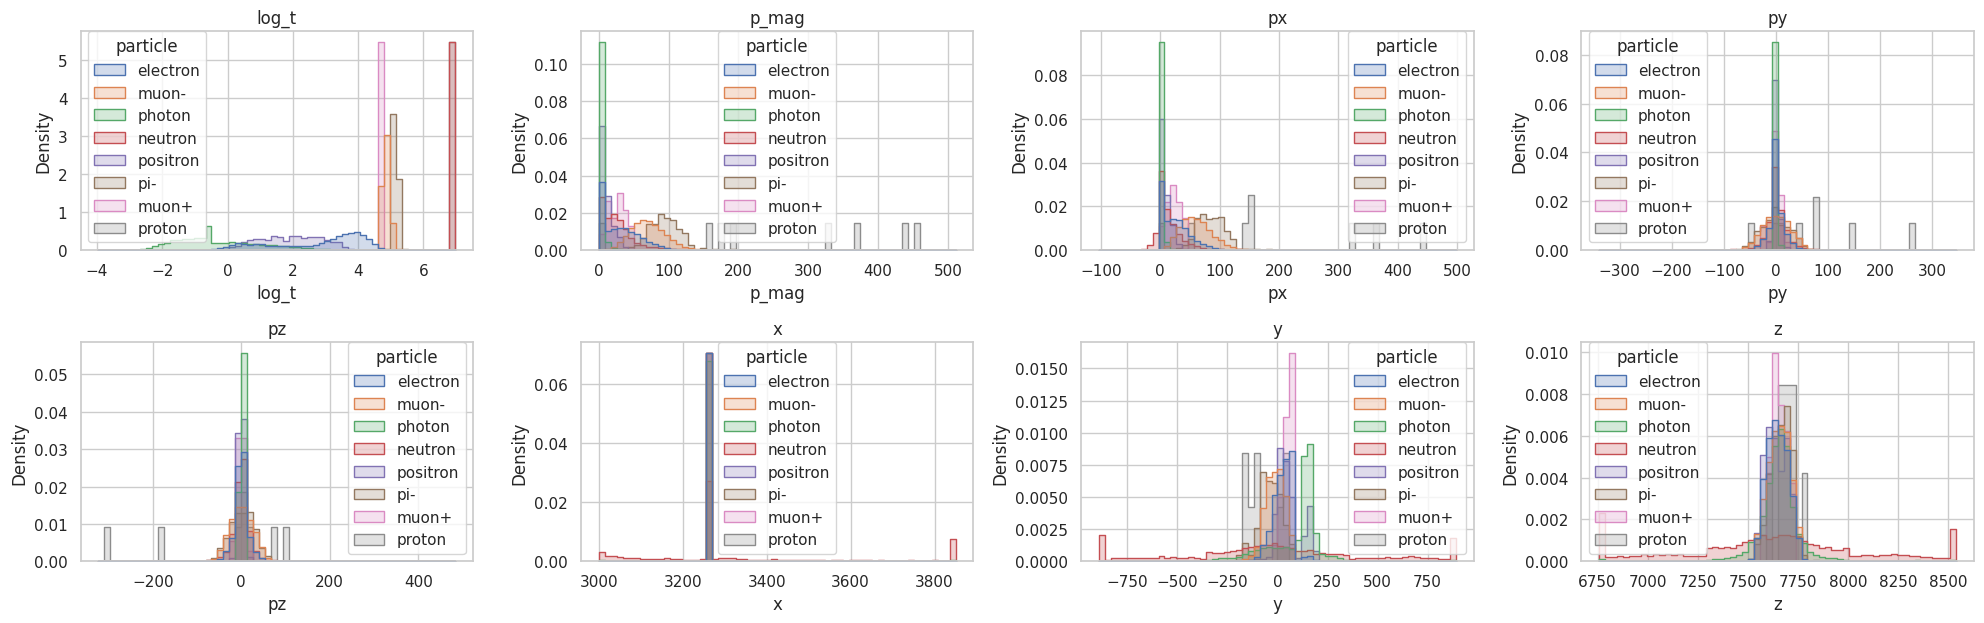

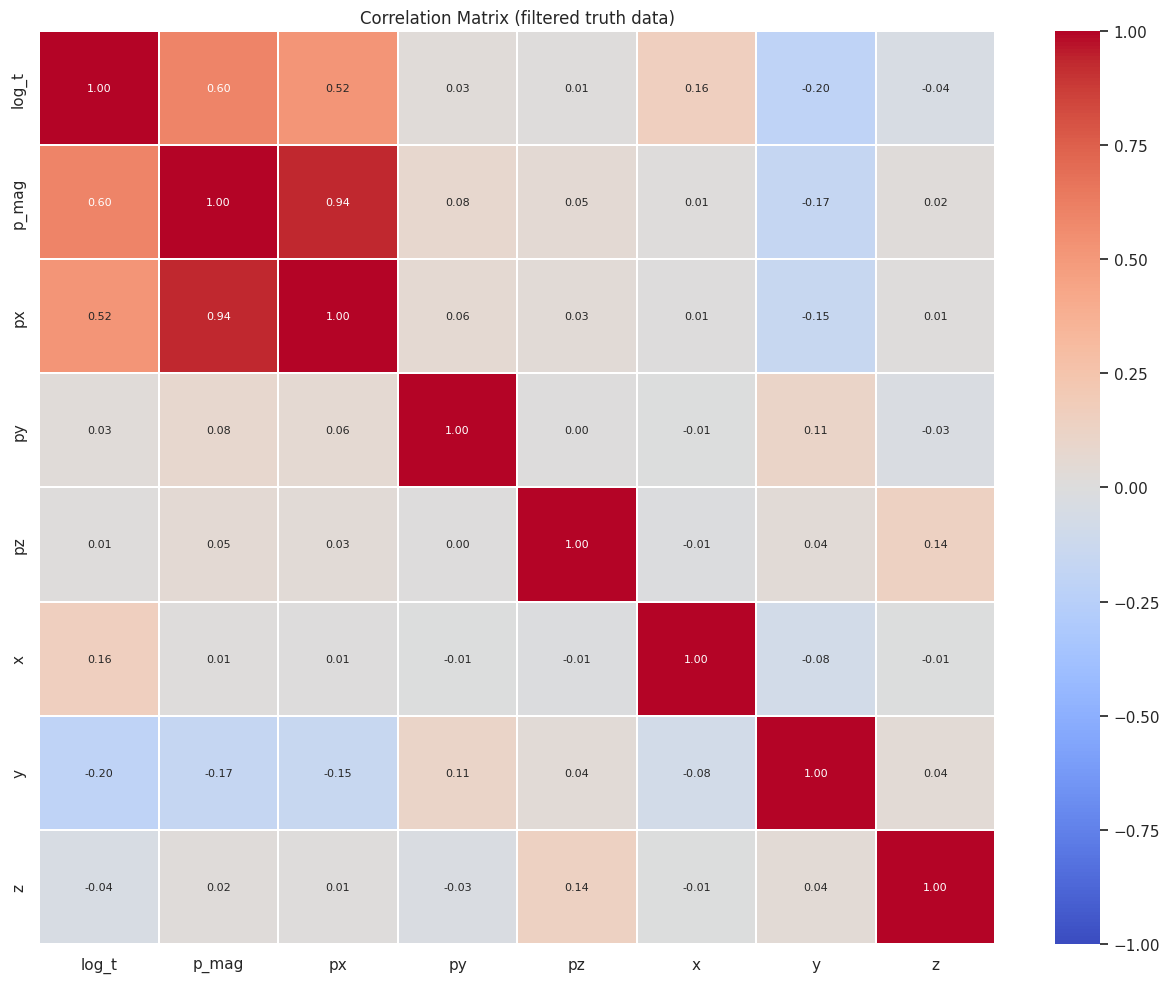

In [5]:
variables = ["log_t", "p_mag", "px", "py", "pz", "x", "y", "z"]
vars_available = [v for v in variables if v in filtered_df.columns]

if len(vars_available) == 0:
    raise ValueError("No variables available for plotting.")

# Means before plotting
print("Means (filtered data):")
print(filtered_df[vars_available].mean(numeric_only=True).to_string(float_format=lambda x: f"{x:.4f}"))

# Marginals
n_cols = 4
n_rows = int(np.ceil(len(vars_available) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(vars_available):
    ax = axes[i]
    sns.histplot(data=plot_df, x=var, hue="particle", stat="density", common_norm=False, bins=60, element="step", ax=ax)
    ax.set_title(var)

for j in range(len(vars_available), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Correlation matrix with numeric annotations
corr = filtered_df[vars_available].corr(numeric_only=True)
plt.figure(figsize=(1.2 * len(vars_available) + 3, 1.0 * len(vars_available) + 2))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.3, linecolor="white")
plt.title("Correlation Matrix (filtered truth data)")
plt.tight_layout()
plt.show()

## 5) 3D Detector-Space View

In [6]:
# Interactive 3D Event Display using Plotly (with equal axes)
import plotly.graph_objects as go
if len(plot_df) == 0:
    raise ValueError("No rows available for 3D plotting after filters.")

particles = sorted(plot_df["particle"].dropna().unique())
palette = dict(zip(particles, sns.color_palette("tab20", n_colors=len(particles))))
colors = plot_df["particle"].map(palette)

# Convert colors to hex for Plotly
def rgb2hex(rgb):
    return '#%02x%02x%02x' % tuple(int(255*x) for x in rgb)

plotly_colors = plot_df["particle"].map(lambda p: rgb2hex(palette[p]))

# Calculate axis ranges for equal aspect ratio
x_vals = plot_df["z"].values
y_vals = plot_df["x"].values
z_vals = plot_df["y"].values
x_min, x_max = x_vals.min(), x_vals.max()
y_min, y_max = y_vals.min(), y_vals.max()
z_min, z_max = z_vals.min(), z_vals.max()
x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
max_range = max(x_range, y_range, z_range)
x_center = (x_max + x_min) / 2
y_center = (y_max + y_min) / 2
z_center = (z_max + z_min) / 2
half_range = max_range / 2
x_axis = [x_center - half_range, x_center + half_range]
y_axis = [y_center - half_range, y_center + half_range]
z_axis = [z_center - half_range, z_center + half_range]

fig = go.Figure()
for p in particles:
    mask = plot_df["particle"] == p
    fig.add_trace(go.Scatter3d(
        x=plot_df.loc[mask, "z"],
        y=plot_df.loc[mask, "x"],
        z=plot_df.loc[mask, "y"],
        mode='markers',
        marker=dict(size=2, color=rgb2hex(palette[p]), opacity=0.3),
        name=p,
        legendgroup=p,
        showlegend=True
    ))

fig.update_layout(
    scene=dict(
        xaxis_title="z",
        yaxis_title="x",
        zaxis_title="y",
        xaxis=dict(range=x_axis),
        yaxis=dict(range=y_axis),
        zaxis=dict(range=z_axis),
        aspectmode='cube'  # Ensures 1:1:1 aspect ratio
    ),
    title="3D Event Display (filtered, interactive, equal axes)",
    legend_title_text="particle",
    margin=dict(l=0, r=0, b=0, t=40)
    # You can adjust camera here if you want a default view
    # scene_camera=dict(eye=dict(x=1.5, y=1.5, z=1.0))
    # But user can rotate freely
    )

fig.show()

## 6) Compact Summary Table

In [7]:
summary_vars = [v for v in ["log_t", "p_mag", "px", "py", "pz", "x", "y", "z"] if v in filtered_df.columns]
summary = (
    filtered_df
    .groupby("particle")[summary_vars]
    .agg(["count", "mean", "std"])
    .sort_values((summary_vars[0], "count"), ascending=False)
)
summary

log_t                      p_mag                             px  \
          count      mean       std  count        mean         std  count   
particle                                                                    
photon    28621 -0.279326  1.276978  28621    1.959252    4.155514  28621   
electron   7578  2.763400  1.381572   7578   30.272079   26.157195   7578   
neutron    7307  6.847558  0.008686   7307   35.244757   51.810060   7307   
muon-      4737  4.852922  0.103248   4737   70.925957   24.271826   4737   
positron   1220  1.912470  0.925609   1220   10.009367    8.852736   1220   
pi-         330  5.127249  0.068035    330   93.629074   20.894946    330   
muon+        27  4.695982  0.028216     27   26.554750   12.120989     27   
proton        8  6.892550  0.041175      8  265.719250  158.517818      8   

                                     py                           pz  \
                mean         std  count       mean        std  count   
particle                                                               
photon      1.523594    3.600900  28621   0.044913   1.730183  28621   
electron   25.259369   23.076711   7578   0.546337  14.642286   7578   
neutron    19.117351   41.049197   7307   1.464859  31.380631   7307   
muon-      60.592295   25.665152   4737   0.476097  25.570136   4737   
positron    8.173443    7.842292   1220   0.206669   4.944903   1220   
pi-        85.083055   22.649013    330  -1.172932  26.822669    330   
muon+      23.069659   11.811836     27  -1.340713   9.712572     27   
proton    203.701670  154.589578      8  70.310552  94.819012      8   

                                     x                               y  \
               mean         std  count         mean         std  count   
particle                                                                 
photon    -0.036575    1.679973  28621  3260.169354   55.415038  28621   
electron   0.050619   14.675366   7578  3258.822031    9.926170   7578   
neutron    0.356814   29.817246   7307  3325.880807  241.553254   7307   
muon-      0.796408   25.200808   4737  3258.960000    0.000000   4737   
positron   0.120420    5.076388   1220  3258.947073    0.832350   1220   
pi-        1.805167   27.045081    330  3258.960000    0.000000    330   
muon+     -1.415191    9.418903     27  3258.960000    0.000000     27   
proton   -35.227618  135.803186      8  3258.960000    0.000000      8   

                                     z                           
               mean         std  count         mean         std  
particle                                                         
photon    93.145586  155.406198  28621  7655.099560  131.612739  
electron  26.934036   56.142087   7578  7646.962883   57.691825  
neutron  -17.833163  461.731975   7307  7621.389577  456.327258  
muon-    -12.709700   47.915405   4737  7655.528583   52.837718  
positron  54.915569   66.137272   1220  7644.376862   61.068468  
pi-      -38.185224   57.433785    330  7664.137719   50.682339  
muon+     52.850164   24.656708     27  7653.676984   38.020573  
proton   -66.744557   85.209162      8  7692.665796   48.038472